## 1. What this notebook computes

Density functional theory at a temperature $T > 0$ (Mermin's theorem) and for
excited states (Delta-SCF) rests on a few exact statements. This notebook checks
each of them with numbers. It

- checks the Gibbs principle: among all density operators of the two-site model,
  the Gibbs state $e^{-(\hat H - \mu\hat N)/T}/Z$ has the lowest grand potential
  $\Omega$, and $\Omega - \Omega_{Gibbs} = T\,D$ with Klein's $D \ge 0$ (2000 random
  density operators);
- checks that the Gibbs state of non-interacting fermions is a product of
  independent orbitals, each occupied with the Fermi-Dirac probability;
- draws the Fermi-Dirac function and finds the chemical potential by bisection;
- computes the thermodynamics of a two-level system (the worked example of the
  chapter) and of a ladder of levels: free energy, energy, entropy, heat capacity,
  with the checks $dF/dT = -S$ and $C_V = T\,dS/dT = dE/dT \ge 0$;
- checks Janak's theorem $\partial E/\partial f_a = \epsilon_a$ and the Delta-SCF
  formula $\Delta_{SCF} = \int_0^1 [\epsilon_L(\tau) - \epsilon_H(\tau)]\,d\tau$ on a
  model energy;
- draws seven teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 13e (Finite temperature (Mermin) and excited states (Delta-SCF)) is the file
`Revision/textbook/notebooks/13e_mermin_delta_scf.ipynb` of the repository Dirac_claude.
It checks the Gibbs principle and Klein's inequality on the 16 states of the two-site
model with 2000 random density operators, shows that the Gibbs state of non-interacting
fermions factorises into independent orbitals with Fermi-Dirac occupations, finds the
chemical potential by bisection, computes the free energy, energy, entropy and heat
capacity of a two-level system (the worked numbers 0.731059, 1.164406, -0.313262,
0.393224) and of a ladder of levels with checks of dF/dT = -S and of the variance formula
for the heat capacity, and checks Janak's theorem and the Delta-SCF integral formula on a
model energy, with seven teaching plots. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy and matplotlib; the other packages run Jupyter, the program that
shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 13e_mermin_delta_scf.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 5 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 13e_mermin_delta_scf.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
13e_mermin_delta_scf.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/13e.captions.json`
- `Revision/textbook/figures/13e_1_gibbs_principle.png`
- `Revision/textbook/figures/13e_2_fermi_dirac.png`
- `Revision/textbook/figures/13e_3_bisection.png`
- `Revision/textbook/figures/13e_4_two_level_thermo.png`
- `Revision/textbook/figures/13e_5_ladder_occupations.png`
- `Revision/textbook/figures/13e_6_ladder_thermo.png`
- `Revision/textbook/figures/13e_7_janak_delta_scf.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 13e_7_janak_delta_scf.png exists
    ALL 23 CHECKS PASSED (notebook 13e)

and the notebook must show 7 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/13e_mermin_delta_scf.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 13e (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 13e (Finite temperature (Mermin) and excited states (Delta-SCF)) is the file
# Revision/textbook/notebooks/13e_mermin_delta_scf.ipynb of the repository Dirac_claude.
# It checks the Gibbs principle and Klein's inequality on the 16 states of the two-site
# model with 2000 random density operators, shows that the Gibbs state of non-interacting
# fermions factorises into independent orbitals with Fermi-Dirac occupations, finds the
# chemical potential by bisection, computes the free energy, energy, entropy and heat
# capacity of a two-level system (the worked numbers 0.731059, 1.164406, -0.313262,
# 0.393224) and of a ladder of levels with checks of dF/dT = -S and of the variance
# formula for the heat capacity, and checks Janak's theorem and the Delta-SCF integral
# formula on a model energy, with seven teaching plots. It needs a computer with Windows
# 11, macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 13e_mermin_delta_scf.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 5
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 13e_mermin_delta_scf.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 13e_mermin_delta_scf.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/13e.captions.json
# - Revision/textbook/figures/13e_1_gibbs_principle.png
# - Revision/textbook/figures/13e_2_fermi_dirac.png
# - Revision/textbook/figures/13e_3_bisection.png
# - Revision/textbook/figures/13e_4_two_level_thermo.png
# - Revision/textbook/figures/13e_5_ladder_occupations.png
# - Revision/textbook/figures/13e_6_ladder_thermo.png
# - Revision/textbook/figures/13e_7_janak_delta_scf.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 13e_7_janak_delta_scf.png exists
#     ALL 23 CHECKS PASSED (notebook 13e)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/13e_mermin_delta_scf.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "13e"  # this notebook: chapter 13, example e


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 13e complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Temperature** $T$: measured as an energy (Boltzmann's constant is set to 1).
- **Density operator** $\hat\rho$: a Hermitian matrix with eigenvalues between 0 and
  1 that add up to 1; it describes a mixture of states with these probabilities.
- **Entropy** $S = -\mathrm{Tr}(\hat\rho\ln\hat\rho) = -\sum_i p_i\ln p_i$, where the
  $p_i$ are the eigenvalues of $\hat\rho$ (with $0\ln 0 = 0$).
- **Chemical potential** $\mu$: the energy that fixes the average particle number.
- **Grand potential** $\Omega[\hat\rho] = \mathrm{Tr}[\hat\rho(\hat H - \mu\hat N)]
  - T S$; **Gibbs state** $\hat\rho_0 = e^{-(\hat H - \mu\hat N)/T}/Z$ with
  $Z = \mathrm{Tr}\,e^{-(\hat H - \mu\hat N)/T}$; $\Omega[\hat\rho_0] = -T\ln Z$.
- **Klein's inequality**: $D = \mathrm{Tr}[\hat\rho(\ln\hat\rho -
  \ln\hat\sigma)] \ge 0$ for two density operators, with equality only when they are
  equal.
- **Fermi-Dirac occupation** $f(\epsilon) = 1/(e^{(\epsilon - \mu)/T} + 1)$: the
  probability that an orbital of energy $\epsilon$ is occupied.
- **Free energy** $F = E - TS$; **heat capacity** $C_V = dE/dT$ at a fixed particle
  number.
- **Bisection**: halving an interval that contains the root until it is small.
- **Janak's theorem**: the derivative of the self-consistent energy with respect to
  the occupation $f_a$ of an orbital is its level $\epsilon_a$.
- **Delta-SCF**: the excitation energy as the difference of two self-consistent
  energies, with one particle moved from the highest occupied orbital (H) to the
  lowest empty one (L).

## 4. The physical and mathematical situation

**Gibbs principle.** For every density operator $\hat\rho$ and the Gibbs state
$\hat\rho_0$: since $\hat H - \mu\hat N = -T\ln\hat\rho_0 - T\ln Z$,

$$\Omega[\hat\rho] = -T\ln Z + T\,\mathrm{Tr}[\hat\rho(\ln\hat\rho -
\ln\hat\rho_0)] = \Omega[\hat\rho_0] + T\,D \ge \Omega[\hat\rho_0] .$$

**Non-interacting fermions.** If $\hat H - \mu\hat N = \sum_a (\epsilon_a - \mu)\hat
n_a$, the weight of the configuration $(n_0, n_1, \dots)$ in the Gibbs state is the
product $\prod_a p_a(n_a)$ with $p_a(1) = f_a$, $p_a(0) = 1 - f_a$: the orbitals are
independent. The entropy is then $S = -\sum_a [f_a\ln f_a + (1 - f_a)\ln(1 - f_a)]$.

**Fixed particle number.** $\sum_a g_a f_a = N$ ($g_a$: the number of states of
level $a$) increases strictly with $\mu$, so exactly one $\mu$ solves it; bisection
finds it. Then $E = \sum g_a f_a\epsilon_a$, $F = E - TS$, and because $F$ is
stationary in the occupations (envelope theorem), $dF/dT = -S$ and
$C_V = dE/dT = T\,dS/dT$. With $w_a = g_a f_a(1 - f_a)$ one finds
$C_V = \frac{1}{T^2}\big[\sum_a w_a(\epsilon_a - \mu)^2 - (\sum_a w_a(\epsilon_a -
\mu))^2/\sum_a w_a\big] \ge 0$ (a weighted variance).

**Janak and Delta-SCF.** For the model energy
$E(f_H, f_L) = \epsilon_H^0 f_H + \epsilon_L^0 f_L + \tfrac{U}{2}(f_H^2 + f_L^2)$
the levels are $\epsilon_a = \partial E/\partial f_a = \epsilon_a^0 + U f_a$. Moving
a fraction $\tau$ from H to L ($f_H = 1 - \tau$, $f_L = \tau$) gives
$dE/d\tau = \epsilon_L(\tau) - \epsilon_H(\tau)$, so
$\Delta_{SCF} = E(0, 1) - E(1, 0) = \int_0^1[\epsilon_L(\tau) - \epsilon_H(\tau)]
\,d\tau$.

**Status.** Exact finite-dimensional statements (PROVED: they follow from the
definitions; this notebook checks each one to rounding); toy numbers, no Revision
record. The Revision Kohn-Sham solver uses the same Mermin occupations with $\mu$
fixed by $\sum g f = N$. That a Delta-SCF state approximates a true excited state is
an ASSUMPTION of the method; Janak's theorem itself is exact.

## 5. The Gibbs principle on the two-site model

The next cell builds the 16 occupation-number states of four orbitals (L up, R up, L
down, R down), the annihilation operators as $16 \times 16$ matrices (with the sign
$(-1)^{\nu_p}$), the two-site Hamiltonian with hopping $t = 1$ and repulsion
$U = 2$, and the particle-number operator.

In [2]:
import itertools  # loops over combinations

import numpy as np  # arrays, matrices and linear algebra

M, DIM = 4, 16  # four orbitals, sixteen occupation-number states
a = []  # annihilation operators
for p in range(M):
    matrix = np.zeros((DIM, DIM))
    for state in range(DIM):
        if (state >> p) & 1:  # orbital p is occupied in this state
            nu = sum((state >> q) & 1 for q in range(p))  # occupied before p
            matrix[state ^ (1 << p), state] = (-1) ** nu
    a.append(matrix)
a_dag = [matrix.T for matrix in a]
n_op = [a_dag[p] @ a[p] for p in range(M)]
N_op = sum(n_op)  # the particle-number operator
H = -(a_dag[0] @ a[1] + a_dag[1] @ a[0] + a_dag[2] @ a[3] + a_dag[3] @ a[2]) \
    + 2.0 * (n_op[0] @ n_op[2] + n_op[1] @ n_op[3])  # t = 1, U = 2
check(np.allclose(H, H.T) and np.allclose(H @ N_op, N_op @ H),
      "H is symmetric and conserves the particle number")

PASS H is symmetric and conserves the particle number


The next cell defines the matrix function $f(A) = \sum_i f(a_i)\,u_i u_i^\dagger$
through the eigenvalues $a_i$ and eigenvectors $u_i$ of a Hermitian matrix, the
entropy, and the grand potential. It builds the Gibbs state at $\mu = 1$, $T = 0.5$
and checks $\Omega[\hat\rho_0] = -T\ln Z$.

In [3]:
MU, TEMPERATURE = 1.0, 0.5
K = H - MU * N_op  # H - mu N


def entropy(rho):
    """S = -sum p ln p over the eigenvalues p of rho (0 ln 0 = 0)."""
    p = np.clip(np.linalg.eigvalsh(rho), 0.0, None)
    p = p[p > 1e-300]
    return float(-np.sum(p * np.log(p)))


def grand_potential(rho):
    """Omega = Tr[rho (H - mu N)] - T S."""
    return float(np.trace(rho @ K).real) - TEMPERATURE * entropy(rho)


k_values, k_vectors = np.linalg.eigh(K)
boltzmann = np.exp(-(k_values - k_values.min()) / TEMPERATURE)  # shifted weights
Z_shifted = boltzmann.sum()
rho_gibbs = (k_vectors * (boltzmann / Z_shifted)) @ k_vectors.T
ln_Z = np.log(Z_shifted) - k_values.min() / TEMPERATURE  # undo the shift
omega_gibbs = grand_potential(rho_gibbs)
report("Omega of the Gibbs state", f"{omega_gibbs:.10f}")
report("-T ln Z", f"{-TEMPERATURE * ln_Z:.10f}")
check(abs(omega_gibbs + TEMPERATURE * ln_Z) < 1e-12, "Omega[Gibbs] = -T ln Z")

RESULT Omega of the Gibbs state = -3.4716265446
RESULT -T ln Z = -3.4716265446
PASS Omega[Gibbs] = -T ln Z


The next cell makes 2000 random density operators: a random complex matrix $A$
gives the density operator $AA^\dagger/\mathrm{Tr}(AA^\dagger)$ (Hermitian, with
non-negative eigenvalues and trace 1); mixing it with the Gibbs state with a random
weight $s$ gives states near and far from the minimum. For each it computes
$\Omega - \Omega_0$ and Klein's $D = \mathrm{Tr}[\hat\rho(\ln\hat\rho -
\ln\hat\rho_0)]$, and checks $\Omega - \Omega_0 = T D \ge 0$.

In [4]:
ln_rho_gibbs = (k_vectors * (-k_values / TEMPERATURE - ln_Z)) @ k_vectors.T


def matrix_log(rho):
    """ln rho through the eigenvalues (all positive here)."""
    values, vectors = np.linalg.eigh(rho)
    return (vectors * np.log(values)) @ vectors.conj().T


rng = np.random.default_rng(12345)  # fixed seed: the same numbers every run
gaps, kleins = [], []
for _ in range(2000):
    A = rng.normal(size=(DIM, DIM)) + 1j * rng.normal(size=(DIM, DIM))
    random_rho = A @ A.conj().T
    random_rho /= np.trace(random_rho).real
    s = rng.uniform(0.0, 1.0)  # how far from the Gibbs state
    rho = (1.0 - s) * rho_gibbs + s * random_rho
    gaps.append(grand_potential(rho) - omega_gibbs)
    kleins.append(np.trace(rho @ (matrix_log(rho) - ln_rho_gibbs)).real)
gaps, kleins = np.array(gaps), np.array(kleins)
say(f"smallest Omega - Omega_0 among 2000 states: {gaps.min():.3e}")
check(np.all(gaps > 0.0), "every random density operator has Omega > Omega[Gibbs]")
check(np.max(np.abs(gaps - TEMPERATURE * kleins)) < 1e-10,
      "Omega - Omega[Gibbs] = T D with Klein's D (identity)")

smallest Omega - Omega_0 among 2000 states: 3.878e-06
PASS every random density operator has Omega > Omega[Gibbs]
PASS Omega - Omega[Gibbs] = T D with Klein's D (identity)


The next cell draws the distribution of $\Omega - \Omega_0$ of the 2000 states as a
histogram on a logarithmic axis.

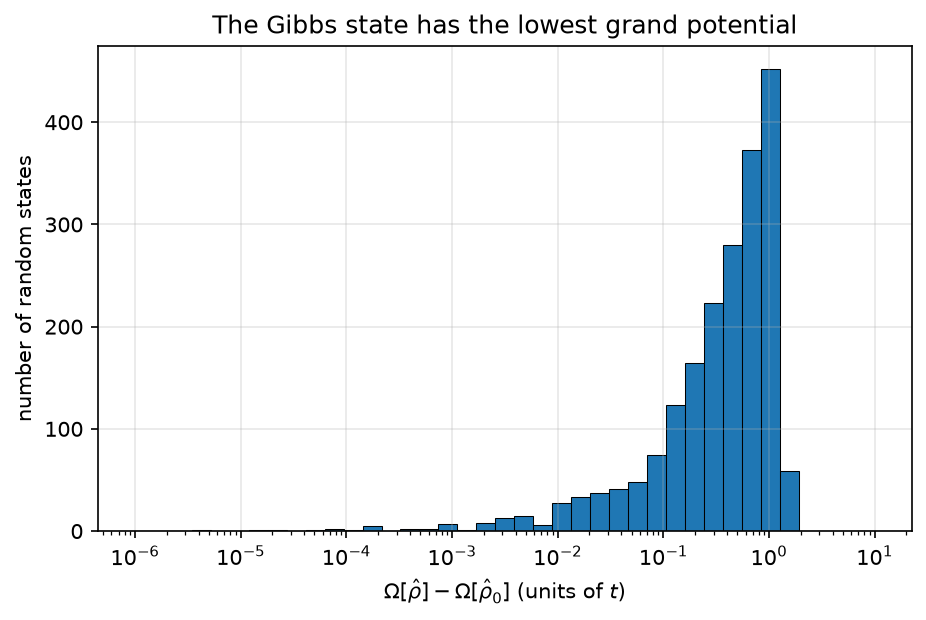

Figure 13e.1 saved as Revision/textbook/figures/13e_1_gibbs_principle.png


In [5]:
fig, ax = plt.subplots()
bins = np.logspace(np.floor(np.log10(gaps.min())), np.ceil(np.log10(gaps.max())), 40)
ax.hist(gaps, bins=bins, color="tab:blue", edgecolor="black", lw=0.5)
ax.set_xscale("log")
ax.set_xlabel("$\\Omega[\\hat\\rho] - \\Omega[\\hat\\rho_0]$ (units of $t$)")
ax.set_ylabel("number of random states")
ax.set_title("The Gibbs state has the lowest grand potential")
save_figure(fig, "gibbs_principle",
            "Histogram of the grand potential of 2000 random density operators of "
            "the two-site model ($t = 1$, $U = 2$, $\\mu = 1$, $T = 0.5$) minus "
            "that of the Gibbs state, on a logarithmic horizontal axis (units of "
            "$t$); the vertical axis counts the states in each bin. All 2000 "
            "differences are positive: no state beats the Gibbs state, as the "
            "Gibbs principle and Klein's inequality say. States mixed only "
            "slightly away from the Gibbs state have the smallest differences.")

## 6. Non-interacting fermions: independent orbitals

The next cell takes three orbitals with energies $-0.5, 0.2, 1.0$, $\mu = 0.1$,
$T = 0.4$, and compares the Gibbs weight $e^{-\sum_a(\epsilon_a - \mu)n_a/T}/Z$ of
each of the 8 configurations with the product of the single-orbital probabilities
$f_a$ or $1 - f_a$.

In [6]:
levels3 = np.array([-0.5, 0.2, 1.0])
mu3, T3 = 0.1, 0.4
configurations = list(itertools.product((0, 1), repeat=3))
weights = np.array([np.exp(-np.dot(levels3 - mu3, c) / T3) for c in configurations])
weights /= weights.sum()  # divide by Z
f3 = 1.0 / (np.exp((levels3 - mu3) / T3) + 1.0)
products = np.array([np.prod([f3[k] if c[k] else 1.0 - f3[k] for k in range(3)])
                     for c in configurations])
for c, wgt, prod in zip(configurations, weights, products):
    say(f"occupations {c}: Gibbs weight {wgt:.6f}, product {prod:.6f}")
check(np.max(np.abs(weights - products)) < 1e-15,
      "the Gibbs weights are products of independent Fermi-Dirac probabilities")

occupations (0, 0, 0): Gibbs weight 0.092777, product 0.092777
occupations (0, 0, 1): Gibbs weight 0.009779, product 0.009779
occupations (0, 1, 0): Gibbs weight 0.072255, product 0.072255
occupations (0, 1, 1): Gibbs weight 0.007616, product 0.007616
occupations (1, 0, 0): Gibbs weight 0.415797, product 0.415797
occupations (1, 0, 1): Gibbs weight 0.043825, product 0.043825
occupations (1, 1, 0): Gibbs weight 0.323823, product 0.323823
occupations (1, 1, 1): Gibbs weight 0.034131, product 0.034131
PASS the Gibbs weights are products of independent Fermi-Dirac probabilities


## 7. The Fermi-Dirac function

The next cell defines $f$ in a form that a computer can evaluate for every
argument: $e^{x}$ overflows (exceeds the largest number the computer can store,
about $10^{308}$) for $x > 709$, so the cell uses $f = e^{-\ln(1 + e^{x})}$ with
numpy's `logaddexp(0, x)` $= \ln(e^0 + e^x)$, which never overflows. It draws
$f(\epsilon)$ for four temperatures around $\mu = 0$ and checks $f(\mu) = 1/2$ and
the symmetry $f(\mu + \delta) = 1 - f(\mu - \delta)$ (a hole below $\mu$ is as
likely as a particle above it).

PASS f(mu) = 1/2 and f(mu + d) = 1 - f(mu - d)


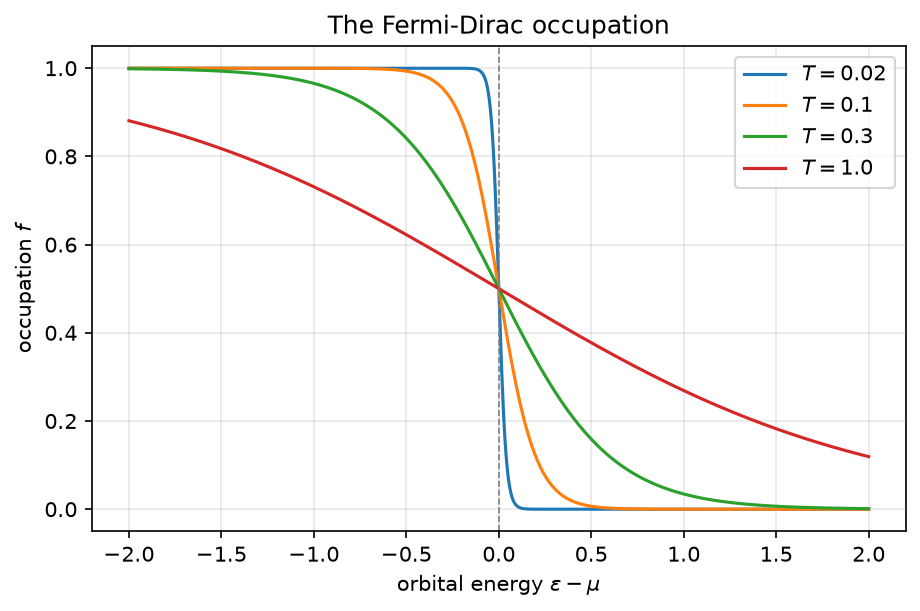

Figure 13e.2 saved as Revision/textbook/figures/13e_2_fermi_dirac.png


In [7]:
def fermi(energy, mu, temperature):
    """The Fermi-Dirac occupation 1 / (exp(x) + 1), x = (energy - mu)/T, written
    as exp(-ln(1 + e^x)) so that no overflow can occur."""
    x = (np.asarray(energy, dtype=float) - mu) / temperature
    return np.exp(-np.logaddexp(0.0, x))


eps = np.linspace(-2.0, 2.0, 801)
check(abs(fermi(0.0, 0.0, 0.3) - 0.5) < 1e-15
      and np.allclose(fermi(eps, 0.0, 0.3), 1.0 - fermi(-eps, 0.0, 0.3), atol=1e-15),
      "f(mu) = 1/2 and f(mu + d) = 1 - f(mu - d)")
fig, ax = plt.subplots()
for temperature in (0.02, 0.1, 0.3, 1.0):
    ax.plot(eps, fermi(eps, 0.0, temperature), label=f"$T = {temperature}$")
ax.axvline(0.0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("orbital energy $\\epsilon - \\mu$")
ax.set_ylabel("occupation $f$")
ax.set_title("The Fermi-Dirac occupation")
ax.legend()
save_figure(fig, "fermi_dirac",
            "The Fermi-Dirac occupation $f = 1/(e^{(\\epsilon - \\mu)/T} + 1)$ "
            "against the orbital energy measured from the chemical potential, for "
            "four temperatures (energies and temperatures in the same units). At "
            "low $T$ it is a step (occupied below $\\mu$, empty above: the aufbau "
            "rule); a higher $T$ smears the step over a width of a few $T$; at "
            "$\\epsilon = \\mu$ it is always 1/2.")

## 8. Two levels, one particle: the chemical potential by bisection

Two levels $\epsilon_0 = 0$, $\epsilon_1 = 1$ (one state each), one particle,
$T = 1/2$. The next cell finds $\mu$ by bisection on $f_0 + f_1 - 1$, starting from
the interval $[-5, 5]$, recording the width of the interval at every step, and
computes the worked numbers of the chapter. The entropy of one state of energy
$\epsilon$ is $-f\ln f - (1 - f)\ln(1 - f)$; with $x = (\epsilon - \mu)/T$ it equals
$\ln(1 + e^{-|x|}) + |x|\,f(|x|)$ (insert $f = 1/(e^x + 1)$ and simplify), a form
without $\ln 0$ that the cell uses.

In [8]:
def chemical_potential(levels, degeneracies, N, temperature, history=None):
    """mu with sum g f = N, by bisection (the sum increases with mu)."""
    low, high = levels.min() - 50.0 * temperature - 5.0, levels.max() + 5.0
    for _ in range(100):
        middle = 0.5 * (low + high)
        if np.sum(degeneracies * fermi(levels, middle, temperature)) < N:
            low = middle  # too few particles: mu must rise
        else:
            high = middle
        if history is not None:
            history.append(high - low)
    return 0.5 * (low + high)


def thermodynamics(levels, degeneracies, N, temperature):
    """mu, occupations, E, S, F of non-interacting levels at fixed N."""
    mu = chemical_potential(levels, degeneracies, N, temperature)
    f = fermi(levels, mu, temperature)
    x = np.abs(levels - mu) / temperature
    s_level = np.logaddexp(0.0, -x) + x * fermi(x, 0.0, 1.0)  # entropy of a state
    S = np.sum(degeneracies * s_level)
    E = np.sum(degeneracies * f * levels)
    return mu, f, E, S, E - temperature * S


two_levels, ones = np.array([0.0, 1.0]), np.array([1.0, 1.0])
widths = []
chemical_potential(two_levels, ones, 1.0, 0.5, widths)
mu2, f2, E2, S2, F2 = thermodynamics(two_levels, ones, 1.0, 0.5)
report("mu", f"{mu2:.6f}")
report("f_0, f_1", f"{f2[0]:.6f}, {f2[1]:.6f}")
report("E, S, F", f"{E2:.6f}, {S2:.6f}, {F2:.6f}")
check(abs(mu2 - 0.5) < 1e-12 and abs(f2[0] - 0.731059) < 1e-6
      and abs(f2[1] - 0.268941) < 1e-6,
      "mu = 1/2, f_0 = 0.731059, f_1 = 0.268941")
check(abs(E2 - 0.268941) < 1e-6 and abs(S2 - 1.164406) < 1e-6
      and abs(F2 + 0.313262) < 1e-6, "E = 0.268941, S = 1.164406, F = -0.313262")

RESULT mu = 0.500000
RESULT f_0, f_1 = 0.731059, 0.268941
RESULT E, S, F = 0.268941, 1.164406, -0.313262
PASS mu = 1/2, f_0 = 0.731059, f_1 = 0.268941
PASS E = 0.268941, S = 1.164406, F = -0.313262


The next cell computes $dF/dT$ and $dE/dT$ by central differences (with $\mu$ solved
again at $T \pm 10^{-4}$), checks $dF/dT = -S$ and $C_V = dE/dT = T\,dS/dT$, and draws
the bisection history.

RESULT dF/dT = -1.164406
RESULT C_V = dE/dT = 0.393224
PASS dF/dT = -S (envelope theorem)
PASS C_V = dE/dT = T dS/dT = 0.393224


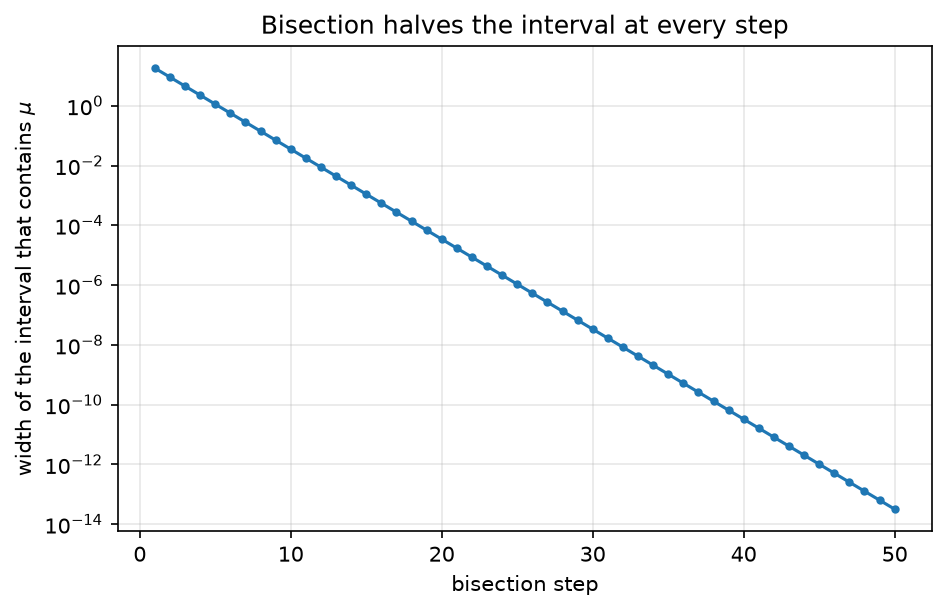

Figure 13e.3 saved as Revision/textbook/figures/13e_3_bisection.png
PASS every bisection step halves the interval


In [9]:
def at(temperature, levels=two_levels, degeneracies=ones, N=1.0):
    return thermodynamics(levels, degeneracies, N, temperature)


d = 1e-4
dF_dT = (at(0.5 + d)[4] - at(0.5 - d)[4]) / (2 * d)
dE_dT = (at(0.5 + d)[2] - at(0.5 - d)[2]) / (2 * d)
T_dS_dT = 0.5 * (at(0.5 + d)[3] - at(0.5 - d)[3]) / (2 * d)
report("dF/dT", f"{dF_dT:.6f}")
report("C_V = dE/dT", f"{dE_dT:.6f}")
check(abs(dF_dT + S2) < 1e-7, "dF/dT = -S (envelope theorem)")
check(abs(dE_dT - 0.393224) < 1e-6 and abs(T_dS_dT - dE_dT) < 1e-7,
      "C_V = dE/dT = T dS/dT = 0.393224")
fig, ax = plt.subplots()
ax.semilogy(range(1, 51), widths[:50], "o-", ms=3)
ax.set_xlabel("bisection step")
ax.set_ylabel("width of the interval that contains $\\mu$")
ax.set_title("Bisection halves the interval at every step")
save_figure(fig, "bisection",
            "The width of the interval that contains the chemical potential during "
            "the bisection for two levels and one particle at $T = 1/2$, against "
            "the step number, on a logarithmic vertical axis (energy units). Every "
            "step halves the width (a straight line that falls by "
            "$\\log_{10} 2 = 0.30$ per step), from 18 after the first step to about "
            "$3 \\times 10^{-14}$ after 50 steps, which fixes $\\mu$ to 13 decimal "
            "places.")
check(all(abs(b / a_ - 0.5) < 1e-12 for a_, b in zip(widths[:40], widths[1:41])),
      "every bisection step halves the interval")

## 9. The two-level system at all temperatures

The next cell computes $E$, $S$, $F$ and $C_V = T\,dS/dT$ (by central differences)
from $T = 0.02$ to $T = 3$, checks the limits ($S \to 0$ as $T \to 0$;
$S \to \ln 4$ and $E \to 1/2$ as $T \to \infty$: the four configurations become
equally likely) and draws them.

PASS S -> 0 for T -> 0; S -> ln 4, E -> 1/2 for T -> infinity
PASS the heat capacity is never negative


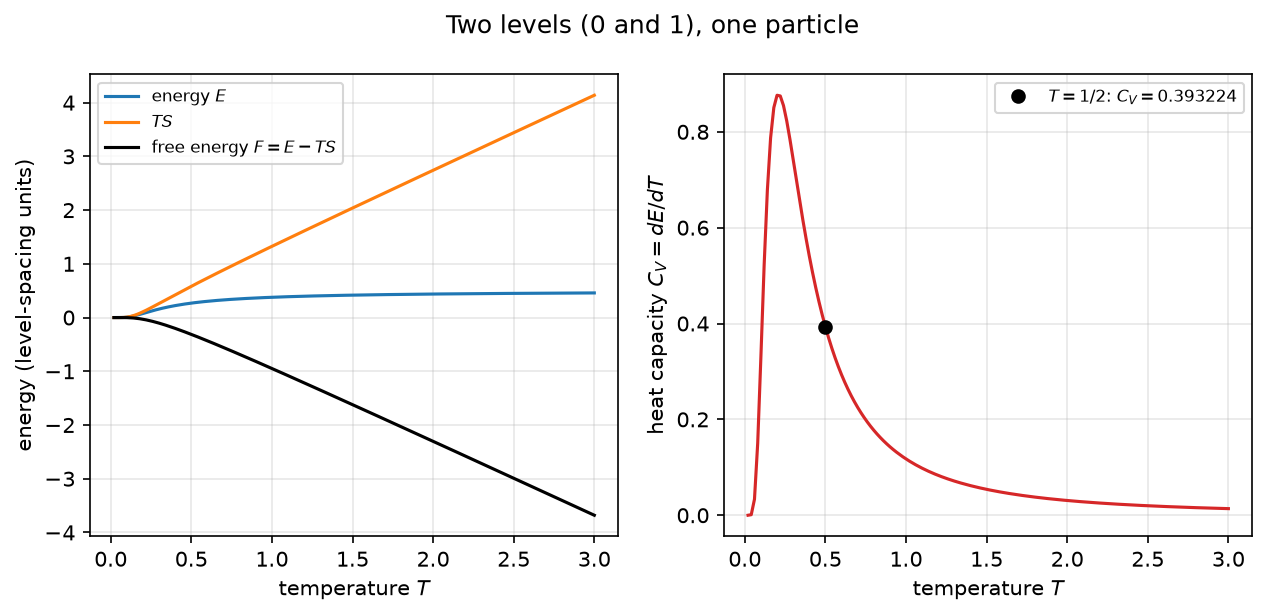

Figure 13e.4 saved as Revision/textbook/figures/13e_4_two_level_thermo.png


In [10]:
temperatures = np.linspace(0.02, 3.0, 150)
table = np.array([at(T)[2:] for T in temperatures])  # columns E, S, F
C_V = np.array([T * (at(T + d)[3] - at(T - d)[3]) / (2 * d) for T in temperatures])
hot = at(1000.0)
check(table[0, 1] < 1e-8 and abs(hot[3] - np.log(4.0)) < 1e-5
      and abs(hot[2] - 0.5) < 1e-3, "S -> 0 for T -> 0; S -> ln 4, E -> 1/2 for T "
      "-> infinity")
check(np.all(C_V >= 0.0), "the heat capacity is never negative")
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
left.plot(temperatures, table[:, 0], label="energy $E$")
left.plot(temperatures, temperatures * table[:, 1], label="$T S$")
left.plot(temperatures, table[:, 2], color="black", label="free energy $F = E - TS$")
left.set_xlabel("temperature $T$")
left.set_ylabel("energy (level-spacing units)")
left.legend(fontsize=8)
right.plot(temperatures, C_V, color="tab:red")
right.plot([0.5], [0.393224], "ko", label="$T = 1/2$: $C_V = 0.393224$")
right.set_xlabel("temperature $T$")
right.set_ylabel("heat capacity $C_V = dE/dT$")
right.legend(fontsize=8)
fig.suptitle("Two levels (0 and 1), one particle")
save_figure(fig, "two_level_thermo",
            "Thermodynamics of one particle in two levels $\\epsilon_0 = 0$, "
            "$\\epsilon_1 = 1$ against the temperature (level-spacing units). "
            "Left: the energy $E$, the product $TS$ of temperature and entropy, "
            "and the free energy $F = E - TS$, which falls with $T$ at the rate "
            "$-S$. Right: the heat capacity $C_V = dE/dT$, which has a single peak "
            "(it vanishes at low $T$, where the upper level is frozen out, and at "
            "high $T$, where both levels are already equally occupied); the black "
            "point is the worked value at $T = 1/2$.")

## 10. A ladder of levels

The next cell takes the levels $\epsilon_n = n + 1/2$ ($n = 0, \dots, 59$), two
states each (two labels), with $N = 8$ particles: the trap of Notebook 13a without
interaction. At low $T$ the four lowest levels are full and $\mu$ lies halfway
between the highest full level 3.5 and the lowest empty level 4.5. The cell computes
$\mu$, $E$, $S$ and $C_V$ (by central differences and by the variance formula of
section 4) for 120 temperatures.

In [11]:
ladder = np.arange(60) + 0.5
twos = 2.0 * np.ones(60)
N_LADDER = 8.0


def ladder_at(T):
    return thermodynamics(ladder, twos, N_LADDER, T)


def variance_heat_capacity(T):
    """C_V = [sum w x^2 - (sum w x)^2 / sum w] / T^2, x = eps - mu, w = g f (1 - f)."""
    mu, f = ladder_at(T)[:2]
    w = twos * f * (1.0 - f)
    x = ladder - mu
    return (np.sum(w * x * x) - np.sum(w * x) ** 2 / np.sum(w)) / T ** 2


T_ladder = np.linspace(0.05, 3.0, 120)
mus = np.array([ladder_at(T)[0] for T in T_ladder])
C_numeric = np.array([(ladder_at(T + d)[2] - ladder_at(T - d)[2]) / (2 * d)
                      for T in T_ladder])
C_variance = np.array([variance_heat_capacity(T) for T in T_ladder])
report("mu at T = 0.05", f"{mus[0]:.6f}")
check(abs(mus[0] - 4.0) < 1e-6, "at low T, mu lies halfway between 3.5 and 4.5")
check(np.max(np.abs(C_numeric - C_variance)) < 1e-5 * max(1.0, C_variance.max()),
      "the heat capacity equals the weighted-variance formula")
check(np.all(C_variance >= 0.0), "the variance formula is never negative")

RESULT mu at T = 0.05 = 4.000000
PASS at low T, mu lies halfway between 3.5 and 4.5
PASS the heat capacity equals the weighted-variance formula
PASS the variance formula is never negative


The next cell draws the occupations of the ladder at four temperatures.

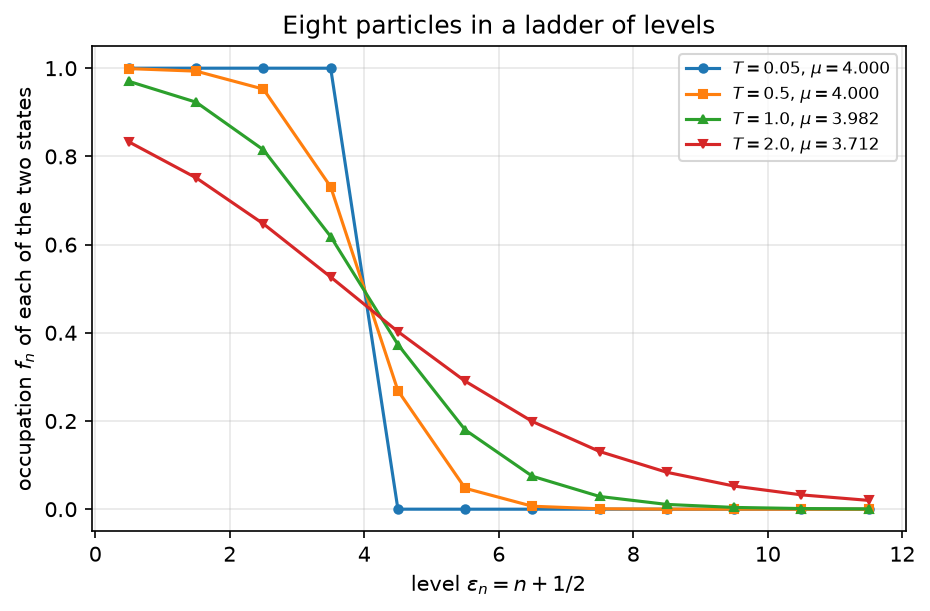

Figure 13e.5 saved as Revision/textbook/figures/13e_5_ladder_occupations.png


In [12]:
fig, ax = plt.subplots()
for T, marker in ((0.05, "o"), (0.5, "s"), (1.0, "^"), (2.0, "v")):
    mu, f = ladder_at(T)[:2]
    ax.plot(ladder[:12], f[:12], marker + "-", ms=4,
            label=f"$T = {T}$, $\\mu = {mu:.3f}$")
ax.set_xlabel("level $\\epsilon_n = n + 1/2$")
ax.set_ylabel("occupation $f_n$ of each of the two states")
ax.set_title("Eight particles in a ladder of levels")
ax.legend(fontsize=8)
save_figure(fig, "ladder_occupations",
            "The Fermi-Dirac occupation of the levels $\\epsilon_n = n + 1/2$ (two "
            "states each) holding eight particles, at four temperatures (energy "
            "units of the level spacing); the chemical potential of each "
            "temperature is in the legend. At $T = 0.05$ the four lowest levels are "
            "full and the others empty; as $T$ grows, particles move from below "
            "$\\mu$ to above it and $\\mu$ falls.")

The next cell draws $\mu$ and $C_V$ of the ladder against the temperature.

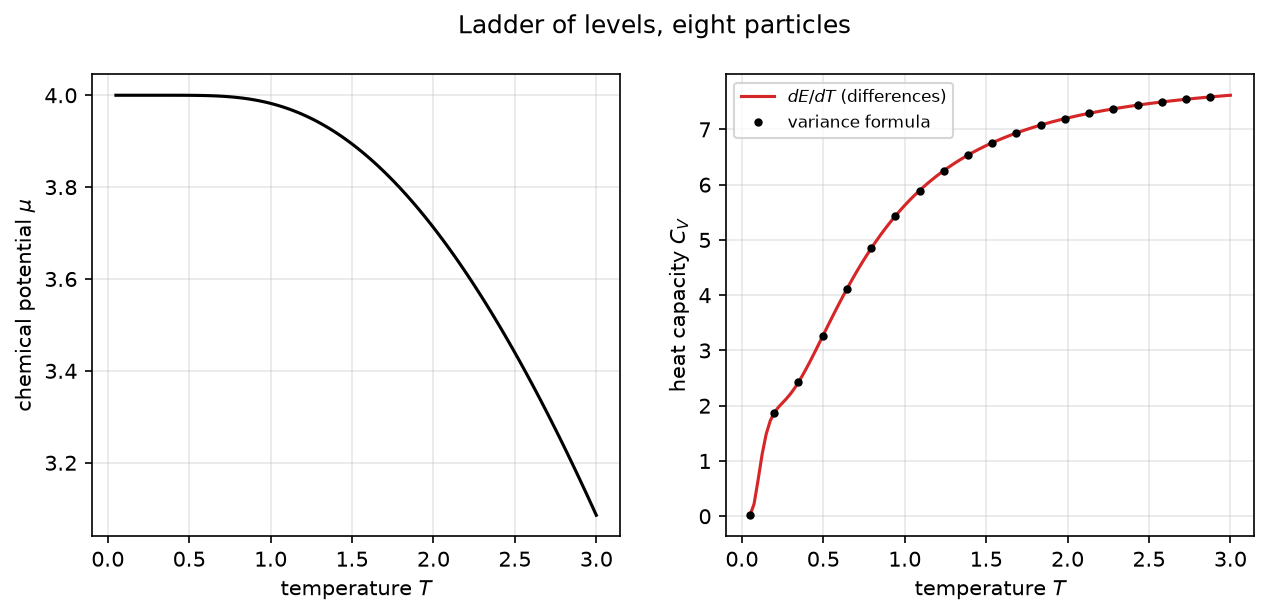

Figure 13e.6 saved as Revision/textbook/figures/13e_6_ladder_thermo.png


In [13]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
left.plot(T_ladder, mus, color="black")
left.set_xlabel("temperature $T$")
left.set_ylabel("chemical potential $\\mu$")
right.plot(T_ladder, C_numeric, color="tab:red", label="$dE/dT$ (differences)")
right.plot(T_ladder[::6], C_variance[::6], "ko", ms=3, label="variance formula")
right.set_xlabel("temperature $T$")
right.set_ylabel("heat capacity $C_V$")
right.legend(fontsize=8)
fig.suptitle("Ladder of levels, eight particles")
save_figure(fig, "ladder_thermo",
            "Left: the chemical potential of eight particles in the ladder "
            "$\\epsilon_n = n + 1/2$ (two states per level) against the "
            "temperature; it starts at 4, halfway between the last full and the "
            "first empty level, and falls as $T$ grows. Right: the heat capacity "
            "from the difference quotient of $E(T)$ (line) and from the "
            "weighted-variance formula (points); they agree, and both are never "
            "negative. Temperatures and energies in units of the level spacing.")

## 11. Janak's theorem and Delta-SCF on a model energy

The next cell takes the model energy of section 4 with $\epsilon_H^0 = 0$,
$\epsilon_L^0 = 1$, $U = 0.2$, checks Janak's theorem by difference quotients,
computes the Kohn-Sham gap $\Delta_{KS} = \epsilon_L - \epsilon_H$ of the ground
state $(f_H, f_L) = (1, 0)$, the Delta-SCF energy $E(0, 1) - E(1, 0)$, the integral
of the level difference over $\tau$ (Simpson's rule) and the transition-state value
at $\tau = 1/2$.

In [14]:
EPS_H0, EPS_L0, U_MODEL = 0.0, 1.0, 0.2


def model_energy(f_H, f_L):
    return EPS_H0 * f_H + EPS_L0 * f_L + 0.5 * U_MODEL * (f_H ** 2 + f_L ** 2)


def model_levels(f_H, f_L):
    """Janak: eps_a = dE/df_a = eps_a^0 + U f_a."""
    return EPS_H0 + U_MODEL * f_H, EPS_L0 + U_MODEL * f_L


h_step = 1e-6
for f_H, f_L in ((1.0, 0.0), (0.5, 0.5), (0.3, 0.9)):
    dE_dfH = (model_energy(f_H + h_step, f_L) - model_energy(f_H - h_step, f_L)) \
        / (2 * h_step)
    dE_dfL = (model_energy(f_H, f_L + h_step) - model_energy(f_H, f_L - h_step)) \
        / (2 * h_step)
    check(np.allclose((dE_dfH, dE_dfL), model_levels(f_H, f_L), atol=1e-9),
          f"Janak: dE/df_a = eps_a at (f_H, f_L) = ({f_H}, {f_L})")
taus = np.linspace(0.0, 1.0, 101)
integrand = np.array([model_levels(1 - t, t)[1] - model_levels(1 - t, t)[0]
                      for t in taus])
gap_KS = integrand[0]
delta_SCF = model_energy(0.0, 1.0) - model_energy(1.0, 0.0)
step = taus[1] - taus[0]
janak_integral = step / 3 * (integrand[0] + integrand[-1]
                             + 4 * integrand[1:-1:2].sum() + 2 * integrand[2:-1:2].sum())
report("Kohn-Sham gap", f"{gap_KS:.6f}")
report("Delta-SCF", f"{delta_SCF:.6f}")
report("integral of eps_L - eps_H over tau", f"{janak_integral:.6f}")
report("transition state (tau = 1/2)", f"{integrand[50]:.6f}")
check(abs(gap_KS - 0.8) < 1e-12 and abs(delta_SCF - 1.0) < 1e-12
      and abs(janak_integral - delta_SCF) < 1e-12 and abs(integrand[50] - 1.0) < 1e-12,
      "gap 0.8, Delta-SCF 1.0 = the Janak integral = the transition state")
check(abs(delta_SCF - gap_KS - U_MODEL) < 1e-12, "Delta-SCF - gap = U (relaxation)")

PASS Janak: dE/df_a = eps_a at (f_H, f_L) = (1.0, 0.0)
PASS Janak: dE/df_a = eps_a at (f_H, f_L) = (0.5, 0.5)
PASS Janak: dE/df_a = eps_a at (f_H, f_L) = (0.3, 0.9)
RESULT Kohn-Sham gap = 0.800000
RESULT Delta-SCF = 1.000000
RESULT integral of eps_L - eps_H over tau = 1.000000
RESULT transition state (tau = 1/2) = 1.000000
PASS gap 0.8, Delta-SCF 1.0 = the Janak integral = the transition state
PASS Delta-SCF - gap = U (relaxation)


The next cell draws the energy along the transfer and the level difference whose
area is the Delta-SCF energy.

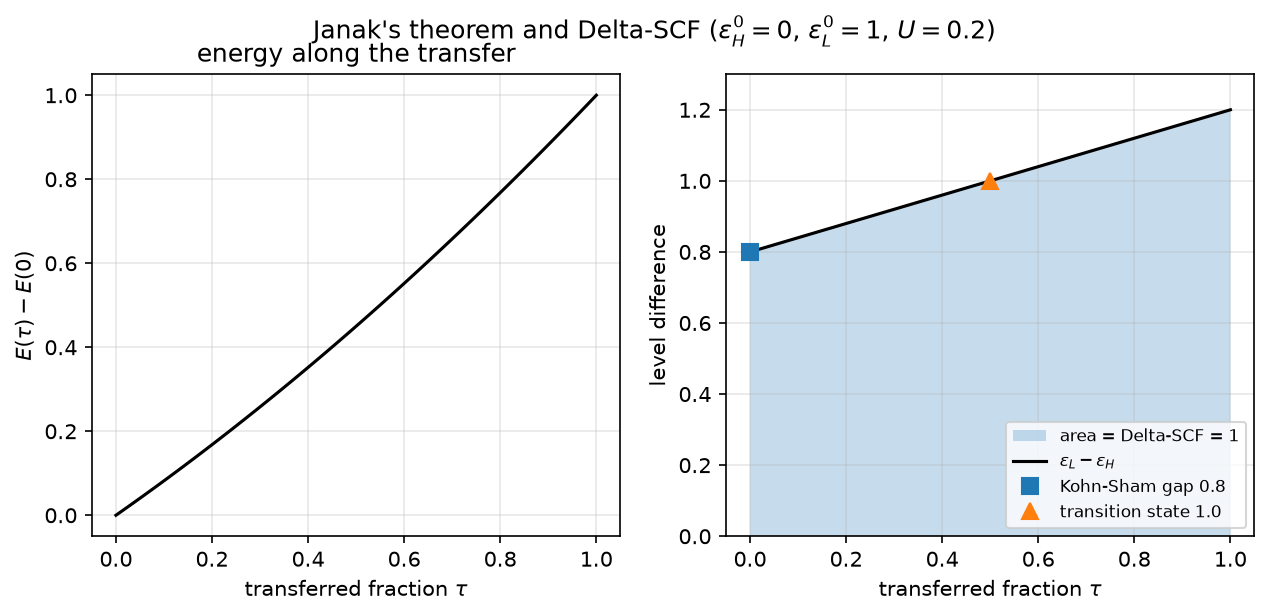

Figure 13e.7 saved as Revision/textbook/figures/13e_7_janak_delta_scf.png


In [15]:
energies_tau = np.array([model_energy(1 - t, t) for t in taus])
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
left.plot(taus, energies_tau - energies_tau[0], color="black")
left.set_xlabel("transferred fraction $\\tau$")
left.set_ylabel("$E(\\tau) - E(0)$")
left.set_title("energy along the transfer")
right.fill_between(taus, 0.0, integrand, alpha=0.25, label="area = Delta-SCF = 1")
right.plot(taus, integrand, color="black", label="$\\epsilon_L - \\epsilon_H$")
right.plot([0.0], [gap_KS], "s", ms=8, label="Kohn-Sham gap 0.8")
right.plot([0.5], [integrand[50]], "^", ms=8, label="transition state 1.0")
right.set_ylim(0.0, 1.3)
right.set_xlabel("transferred fraction $\\tau$")
right.set_ylabel("level difference")
right.legend(fontsize=8, loc="lower right")
fig.suptitle("Janak's theorem and Delta-SCF ($\\epsilon_H^0 = 0$, "
             "$\\epsilon_L^0 = 1$, $U = 0.2$)")
save_figure(fig, "janak_delta_scf",
            "The model energy $E = \\epsilon_H^0 f_H + \\epsilon_L^0 f_L + "
            "(U/2)(f_H^2 + f_L^2)$ when a fraction $\\tau$ of a particle is moved "
            "from H to L (left: the energy gained, rising to 1), and the level "
            "difference $\\epsilon_L - \\epsilon_H = 0.8 + 0.4\\tau$, which is the "
            "slope of the left curve by Janak's theorem (right). The Kohn-Sham gap "
            "0.8 is the value at $\\tau = 0$; the area, the Delta-SCF energy 1.0, "
            "exceeds it by $U = 0.2$ (orbital relaxation), and the midpoint value "
            "(transition state) is exact here because the line is straight.")

## 12. The last check

The last cell checks that all seven figure files exist and prints the number of
checks that passed.

In [16]:
figure_names = ["gibbs_principle", "fermi_dirac", "bisection", "two_level_thermo",
                "ladder_occupations", "ladder_thermo", "janak_delta_scf"]
missing = [name for k, name in enumerate(figure_names, 1)
           if not output_file(f"{FIGURE_FOLDER}/13e_{k}_{name}.png").is_file()]
check(missing == [], "all seven figure files exist")
check(output_file(f"{FIGURE_FOLDER}/13e_7_janak_delta_scf.png").is_file(),
      "the figure file 13e_7_janak_delta_scf.png exists")
all_checks_passed()

PASS all seven figure files exist
PASS the figure file 13e_7_janak_delta_scf.png exists
ALL 23 CHECKS PASSED (notebook 13e)


## 13. What this notebook showed

- The Gibbs state has the lowest grand potential of all density operators; the
  excess of any other state is $T$ times Klein's $D \ge 0$ (2000 random states).
  This is the variational principle behind Mermin's finite-temperature DFT.
- For non-interacting fermions the Gibbs state is a product of independent orbitals
  with the Fermi-Dirac occupations; the entropy is the sum of the orbital entropies.
- The chemical potential is found by bisection from $\sum g f = N$; every step halves
  the interval.
- Two levels at $T = 1/2$: $f_0 = 0.731059$, $E = 0.268941$, $S = 1.164406$,
  $F = -0.313262$, $dF/dT = -S$, $C_V = 0.393224$; the heat capacity has one peak.
- For a ladder of levels the heat capacity from $dE/dT$ equals the weighted-variance
  formula, so it is never negative.
- Janak's theorem holds, and the Delta-SCF excitation energy is the integral of the
  level difference over the transferred fraction; in the model it exceeds the
  Kohn-Sham gap by $U$.